# Airbnb EDA — Analysis Notebook (v2)
Separate from the cleaning notebook (`airbnb_eda_v2.ipynb`) — this one starts
from the already-cleaned CSV and only does analysis: univariate, bivariate,
and multivariate, each paired with the plot type that fits its data shape.

**Deliberately structured opposite to the GeeksforGeeks reference article**
(`airbnb-booking-analysis-using-eda`), which only produces 5 charts, all
univariate or simple two-variable bivariate: a price histogram, a room_type
count plot, a neighbourhood_group count plot, a price-by-room_type boxplot,
and a reviews-over-time line plot. It never crosses three variables and never
opens `calculated_host_listings_count`, `instant_bookable`,
`cancellation_policy`, `availability_365`, `lat`/`long`, `service_fee`, or
`construction_year`.

So here: univariate/bivariate sections below are kept short and deliberately
use different columns than the reference already covers. The real weight is
in the multivariate section, which the reference has none of at all.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
PALETTE = "colorblind"
COLORS = sns.color_palette(PALETTE)

path = r"C:\Users\yashv\OneDrive\Desktop\PROJECTS\air_bn\airbnb_cleaned_v2.csv"
df = pd.read_csv(path, low_memory=False)
df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')

# Two stray typo categories slipped through the cleaning pass ('brookln',
# 'manhatan') - fixed here since every neighbourhood_group chart below would
# otherwise carry two spurious 1-row "groups".
df['neighbourhood_group'] = df['neighbourhood_group'].replace({
    'brookln': 'Brooklyn',
    'manhatan': 'Manhattan'
})

print(df.shape)
df.head()

(100115, 25)


,id,name,host_id,host_identity_verified,host_name,neighbourhood_group,neighbourhood,lat,long,country,...,price,service_fee,minimum_nights,number_of_reviews,last_review,reviews_per_month,review_rate_number,calculated_host_listings_count,availability_365,house_rules
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,966.0,193.0,10.0,9.0,2021-10-19,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,142.0,28.0,30.0,45.0,2022-05-21,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,Unknown,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,620.0,124.0,3.0,0.0,NaT,0.00,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and..."
3,1002755,Unknown,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,368.0,74.0,30.0,270.0,2019-07-05,4.64,4.0,1.0,322.0,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,204.0,41.0,10.0,9.0,2018-11-19,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th..."


## Section 1 — Univariate
Quick baseline only, and deliberately on columns the reference article never
plots at all — it only covers `price`, `room_type`, and `neighbourhood_group`.
Those three get their real treatment later, folded into the multivariate
questions below rather than repeated here as standalone charts.

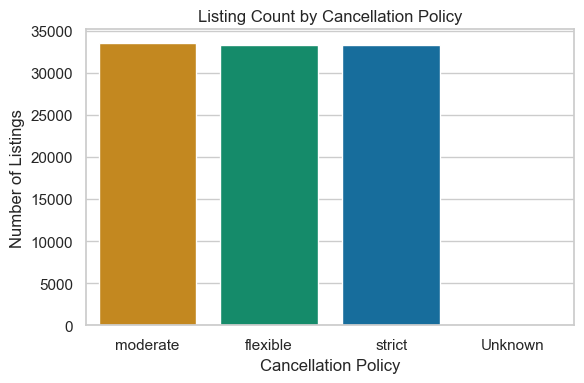

In [2]:
order = df['cancellation_policy'].value_counts().index

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='cancellation_policy', order=order,
              hue='cancellation_policy', palette=PALETTE, legend=False)
plt.title('Listing Count by Cancellation Policy')
plt.xlabel('Cancellation Policy')
plt.ylabel('Number of Listings')
plt.tight_layout()
plt.show()

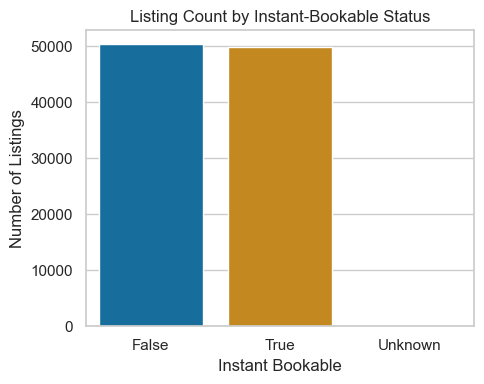

In [3]:
order = df['instant_bookable'].value_counts().index

plt.figure(figsize=(5, 4))
sns.countplot(data=df, x='instant_bookable', order=order,
              hue='instant_bookable', palette=PALETTE, legend=False)
plt.title('Listing Count by Instant-Bookable Status')
plt.xlabel('Instant Bookable')
plt.ylabel('Number of Listings')
plt.tight_layout()
plt.show()

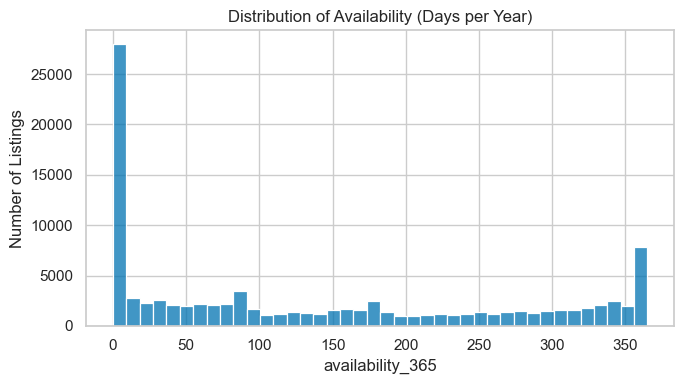

In [4]:
plt.figure(figsize=(7, 4))
sns.histplot(df['availability_365'], bins=40, color=COLORS[0])
plt.title('Distribution of Availability (Days per Year)')
plt.xlabel('availability_365')
plt.ylabel('Number of Listings')
plt.tight_layout()
plt.show()

## Section 2 — Bivariate
Supporting evidence for the multivariate questions below, not standalone
centerpieces. Also paired differently than the reference on purpose: it boxes
`price` against `room_type` — here `price` is boxed against
`neighbourhood_group` instead, since the room_type pairing is already covered
by the article.

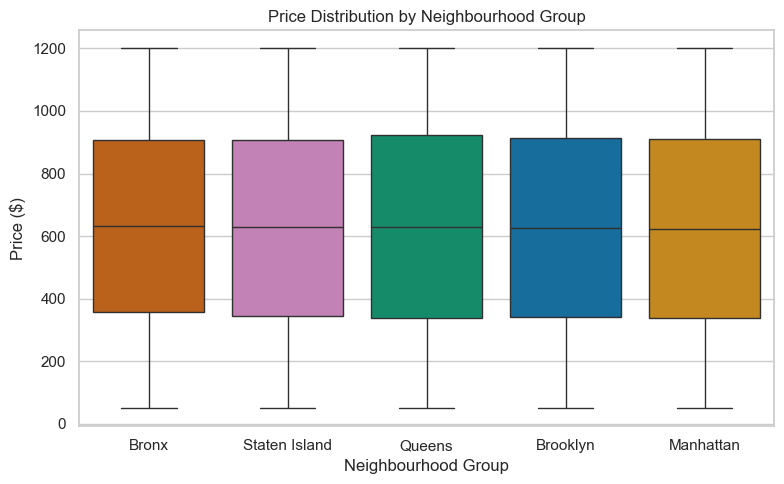

In [5]:
order = df.groupby('neighbourhood_group')['price'].median().sort_values(ascending=False).index

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='neighbourhood_group', y='price', order=order,
            hue='neighbourhood_group', palette=PALETTE, legend=False)
plt.title('Price Distribution by Neighbourhood Group')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Price ($)')
plt.tight_layout()
plt.show()

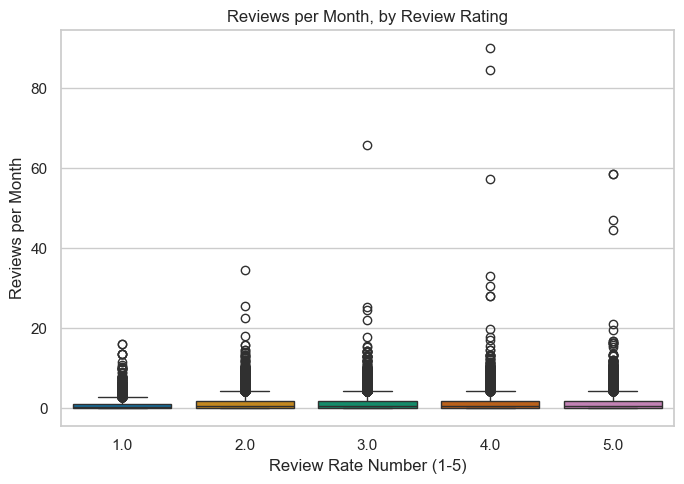

In [6]:
# review_rate_number is a discrete 1-5 scale, not continuous - a boxplot per
# rating level shows the reviews_per_month distribution better than a scatter
# would (a scatter would just be five overlapping vertical strips).
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='review_rate_number', y='reviews_per_month',
            hue='review_rate_number', palette=PALETTE, legend=False)
plt.title('Reviews per Month, by Review Rating')
plt.xlabel('Review Rate Number (1-5)')
plt.ylabel('Reviews per Month')
plt.tight_layout()
plt.show()

## Section 3 — Multivariate (the centerpiece)
The reference article has no multivariate analysis at all — nothing there
ever crosses more than two variables. Everything below crosses three, and
several use columns (`calculated_host_listings_count`, `instant_bookable`,
`cancellation_policy`, `availability_365`, `construction_year`) it never
opens.

### Q1 — Which neighbourhood groups are most popular, and what does their price-tier mix look like?
Price tiers (`Cheap` / `Moderate` / `Luxury`) are computed **within each
neighbourhood_group** using per-group tertiles, not a global cutoff — a
global cutoff would let Manhattan dominate every luxury bucket by default
regardless of its actual within-group pricing.

In [7]:
def tier_within_group(prices):
    return pd.qcut(prices, q=3, labels=['Cheap', 'Moderate', 'Luxury'], duplicates='drop')

df['price_tier'] = df.groupby('neighbourhood_group')['price'].transform(tier_within_group)

df[['neighbourhood_group', 'price', 'price_tier']].sample(5, random_state=1)

,neighbourhood_group,price,price_tier
30236,Queens,588.0,Moderate
35446,Manhattan,221.0,Cheap
33081,Brooklyn,192.0,Cheap
76248,Manhattan,752.0,Moderate
10512,Manhattan,833.0,Luxury


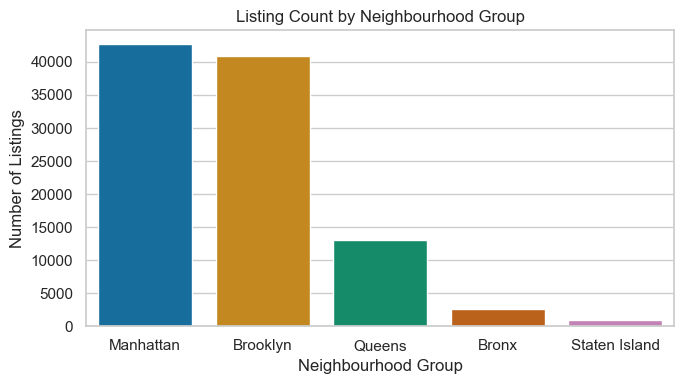

In [8]:
# Popularity half of Q1 - feeds directly into the heatmap below, not a
# standalone repeat of the reference's isolated neighbourhood_group countplot.
group_counts = df['neighbourhood_group'].value_counts()

plt.figure(figsize=(7, 4))
sns.barplot(x=group_counts.index, y=group_counts.values,
            hue=group_counts.index, palette=PALETTE, legend=False)
plt.title('Listing Count by Neighbourhood Group')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Number of Listings')
plt.tight_layout()
plt.show()

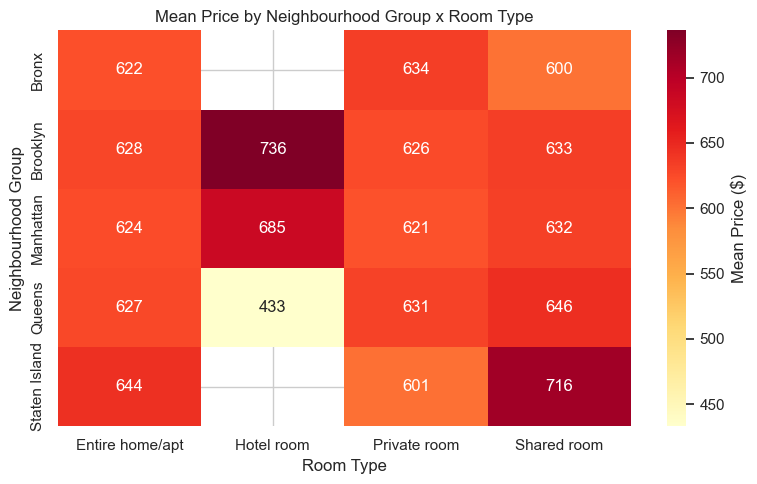

In [9]:
pivot = df.pivot_table(index='neighbourhood_group', columns='room_type', values='price', aggfunc='mean')

plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', cbar_kws={'label': 'Mean Price ($)'})
plt.title('Mean Price by Neighbourhood Group x Room Type')
plt.xlabel('Room Type')
plt.ylabel('Neighbourhood Group')
plt.tight_layout()
plt.show()

### Q2 — Among the cheapest price-tier listings, which neighbourhoods also have the lowest minimum-night requirements?
Filtered to the `Cheap` tier computed above, then ranked individual
neighbourhoods (not groups) by median `minimum_nights` — this is where a
short, affordable stay is easiest to book. Restricted to neighbourhoods with
at least 5 cheap-tier listings so a single listing can't fake a rank.

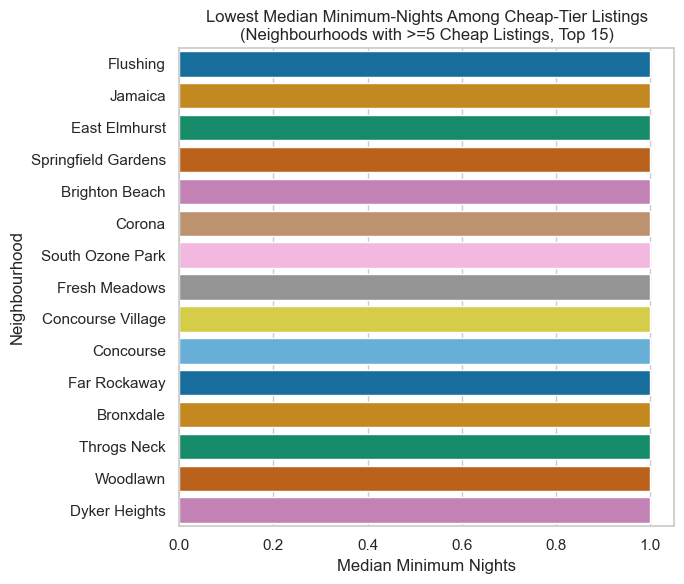

In [10]:
cheap = df[df['price_tier'] == 'Cheap']

cheap_stats = cheap.groupby('neighbourhood')['minimum_nights'].agg(['median', 'count'])
cheap_stats = cheap_stats[cheap_stats['count'] >= 5]
cheap_stats = cheap_stats.sort_values(['median', 'count'], ascending=[True, False]).head(15)

plt.figure(figsize=(7, 6))
sns.barplot(x=cheap_stats['median'], y=cheap_stats.index,
            hue=cheap_stats.index, palette=PALETTE, legend=False)
plt.title('Lowest Median Minimum-Nights Among Cheap-Tier Listings\n(Neighbourhoods with >=5 Cheap Listings, Top 15)')
plt.xlabel('Median Minimum Nights')
plt.ylabel('Neighbourhood')
plt.tight_layout()
plt.show()

### Q3 — Which hosts hold the most listings, and are they concentrated in specific neighbourhood groups or price levels?
`calculated_host_listings_count` is severely skewed (median 1, mean ~8, max
332 in this dataset) — a handful of power-hosts. Bubble chart, log-scaled
x-axis, top 30 hosts by listings count.

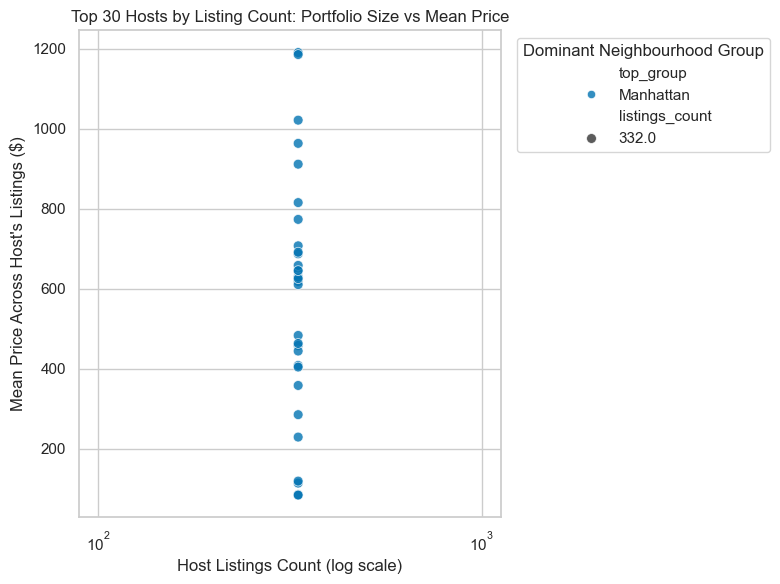

In [11]:
host_stats = (
    df.groupby('host_id')
    .agg(
        listings_count=('calculated_host_listings_count', 'max'),
        mean_price=('price', 'mean'),
        top_group=('neighbourhood_group', lambda s: s.mode().iat[0])
    )
    .sort_values('listings_count', ascending=False)
    .head(30)
)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=host_stats, x='listings_count', y='mean_price',
    hue='top_group', size='listings_count', sizes=(50, 400),
    palette=PALETTE, alpha=0.8
)
plt.xscale('log')
plt.title("Top 30 Hosts by Listing Count: Portfolio Size vs Mean Price")
plt.xlabel('Host Listings Count (log scale)')
plt.ylabel("Mean Price Across Host's Listings ($)")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Dominant Neighbourhood Group')
plt.tight_layout()
plt.show()

### Q4 — Do listings with high availability also get more reviews per month, and does that differ by room type?

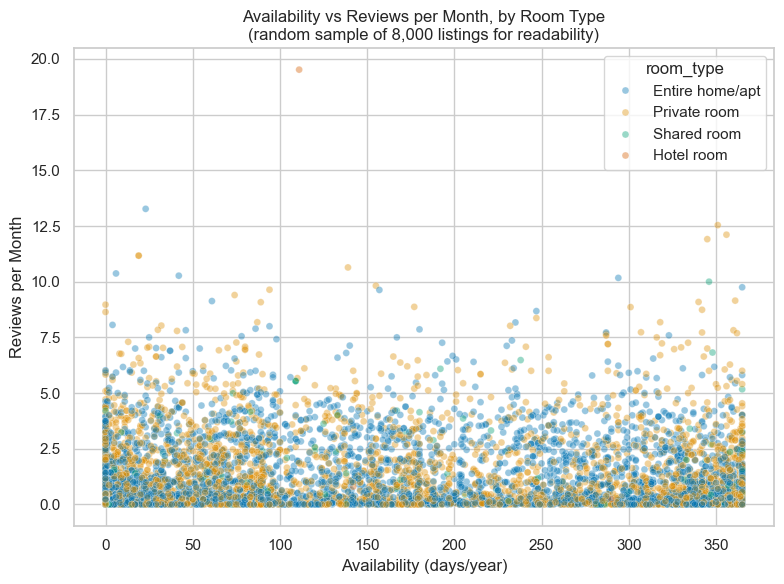

In [12]:
# Random sample for readability - 100k overlapping points would otherwise
# hide the pattern regardless of alpha transparency.
sample = df.dropna(subset=['availability_365', 'reviews_per_month']).sample(
    n=min(8000, len(df)), random_state=1
)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=sample, x='availability_365', y='reviews_per_month',
    hue='room_type', alpha=0.4, palette=PALETTE, s=25
)
plt.title('Availability vs Reviews per Month, by Room Type\n(random sample of 8,000 listings for readability)')
plt.xlabel('Availability (days/year)')
plt.ylabel('Reviews per Month')
plt.tight_layout()
plt.show()

### Q5 — Does instant-bookable status correlate with a stricter or looser cancellation policy, and does that pattern hold across room types?

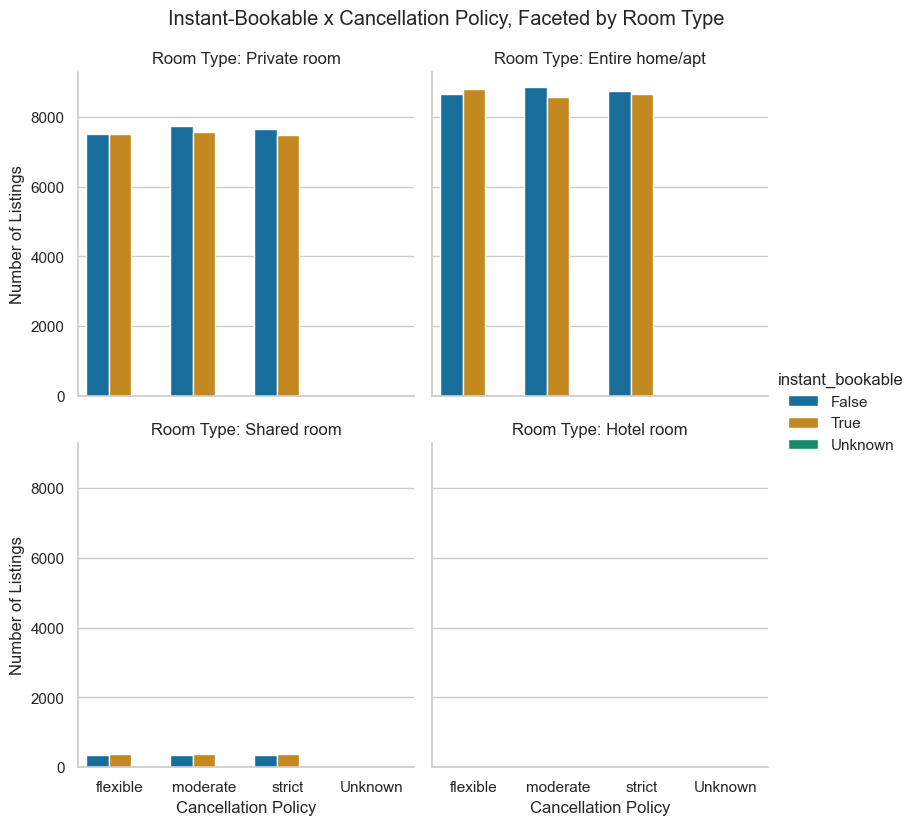

In [13]:
g = sns.catplot(
    data=df, x='cancellation_policy', hue='instant_bookable', col='room_type',
    kind='count', palette=PALETTE, col_wrap=2, height=4,
    order=['flexible', 'moderate', 'strict', 'Unknown']
)
g.set_axis_labels('Cancellation Policy', 'Number of Listings')
g.set_titles('Room Type: {col_name}')
g.fig.suptitle('Instant-Bookable x Cancellation Policy, Faceted by Room Type', y=1.03)
plt.show()

### Bonus Q6 — Does "newer construction = higher price" hold uniformly, or only in specific boroughs?
Column the reference never opens at all (`construction_year`), crossed with
both `price` and `neighbourhood_group`.

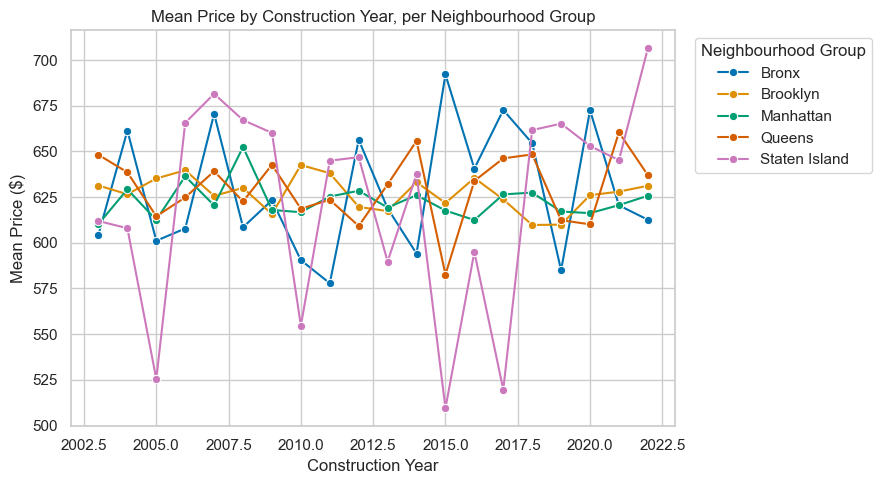

In [14]:
trend = (
    df.groupby(['construction_year', 'neighbourhood_group'])['price']
    .mean()
    .reset_index()
)

plt.figure(figsize=(9, 5))
sns.lineplot(data=trend, x='construction_year', y='price',
             hue='neighbourhood_group', palette=PALETTE, marker='o')
plt.title('Mean Price by Construction Year, per Neighbourhood Group')
plt.xlabel('Construction Year')
plt.ylabel('Mean Price ($)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Neighbourhood Group')
plt.tight_layout()
plt.show()

## Summary
Structured opposite to the reference on purpose: minimal univariate/bivariate
hygiene checks up front, using columns it doesn't already cover, with six
genuinely multivariate questions carrying the actual analysis — none of
which the reference could produce, since it never crosses more than two
variables and never opens the host, policy, availability, or construction-year
columns used here.